# Connected RNN Perturbation Analysis

This notebook reproduces the connected RNN perturbation experiments.

The analysis compares:
- Region A neuron knockout perturbations
- Region B neuron knockout perturbations
- Both Region A and B knockout perturbations

The notebook includes generation/loading all transition dictionaries, perturbation experiments, Stage 2 & 3 error analysis, frozen-state analysis, and behavioral-state analysis.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

%load_ext autoreload
%autoreload 2
print("Project root:", PROJECT_ROOT)
print("Working directory:", os.getcwd())

Project root: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model
Working directory: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

import cm_analysis as cma
import perturbation_testing as pt
import cm_experiments as cme

print("Imports successful")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/neelprabhakar/Python /.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful


## Experiment Configuration

Set the random seed and perturbation parameters used throughout the connected RNN experiment.

In [3]:
import random

SEED = 42
TOTAL_PERTURBATIONS = 4000

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)
print("Perturbations per condition:", TOTAL_PERTURBATIONS)

Seed: 42
Device: mps
Perturbations per condition: 4000


## Initialize Connected RNN

Initialize the connected two-region RNN using the same random seed as the original experiment.

The model is not trained with gradient descent. Its randomly initialized weights are saved so that the original and perturbed analyses use the same model.

In [4]:
model = cme.cm.connected_models().to(device)
model.eval()

CONNECTED_MODEL_PATH = os.path.join(PROJECT_ROOT, "post_stage1_connected_model_sd42.pt")
torch.save(model.state_dict(), CONNECTED_MODEL_PATH)

print("Connected model initialized.")
print("Model saved to:", CONNECTED_MODEL_PATH)

Connected model initialized.
Model saved to: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model/post_stage1_connected_model_sd42.pt


## Original Transition Dictionaries

Generate or load the original transition dictionaries produced by the unperturbed connected RNN.

The dictionaries characterize transitions for behavioral states, each neural region independently, neural-behavioral pairs, and the joint two-region state.

In [5]:
b_transition_dict, all_visit_b_count_dict, Na_transition_dict, Nb_transition_dict, Na_Nb_transition_dict, Na_b_transition_dict, Nb_b_transition_dict, Na_Nb_b_transition_dict = cme.generate_dicts(model)

print("Original transition dictionaries ready.")
print("Behavioral states:", len(b_transition_dict))
print("Region A neural states:", len(Na_transition_dict))
print("Region B neural states:", len(Nb_transition_dict))
print("Joint neural states:", len(Na_Nb_transition_dict))
print("Joint neural-behavioral states:", len(Na_Nb_b_transition_dict))

[Log] cache already exists for min_visits=100
Original transition dictionaries ready.
Behavioral states: 400
Region A neural states: 1113
Region B neural states: 604
Joint neural states: 7124
Joint neural-behavioral states: 20000


## Connected RNN Knockout Experiments

Run three perturbation conditions:

- Region A knockout
- Region B knockout
- Simultaneous Region A and Region B knockout

At each perturbation step, a neuron is knocked out and the resulting transition behavior is compared with the original transition dictionaries.

In [6]:
PERTURBATION_CACHE_DIR = os.path.join(PROJECT_ROOT, "Perturbation_Connected_Cache")

perturbation_results = cme.run_connected_knockout_experiments(model, b_transition_dict, Na_transition_dict, Nb_transition_dict, Na_b_transition_dict, Nb_b_transition_dict, Na_Nb_transition_dict, Na_Nb_b_transition_dict, total_perturbations=TOTAL_PERTURBATIONS, sd=SEED, save_dir=PERTURBATION_CACHE_DIR)

print("Connected knockout experiments complete.")

[Log] perturbation cache already exists for n=4000
Connected knockout experiments complete.


## Stage 2: Dynamic Perturbation Error

Stage 2 measures how the transition probabilities encountered along the perturbed trajectory differ from the original transition probabilities.

For each perturbation condition, the faded traces show the raw Stage 2 error and the solid traces show Gaussian-smoothed trends. Frozen-state frequency is shown separately below each error plot.

In [7]:
stage2_histories = {region: perturbation_results[region]["stage2_error_history"] for region in ("a", "b", "both")}

for region in ("a", "b", "both"):
    print(f"{region}:\n{len(stage2_histories[region])} Stage 2 steps")

a:
4000 Stage 2 steps
b:
4000 Stage 2 steps
both:
4000 Stage 2 steps


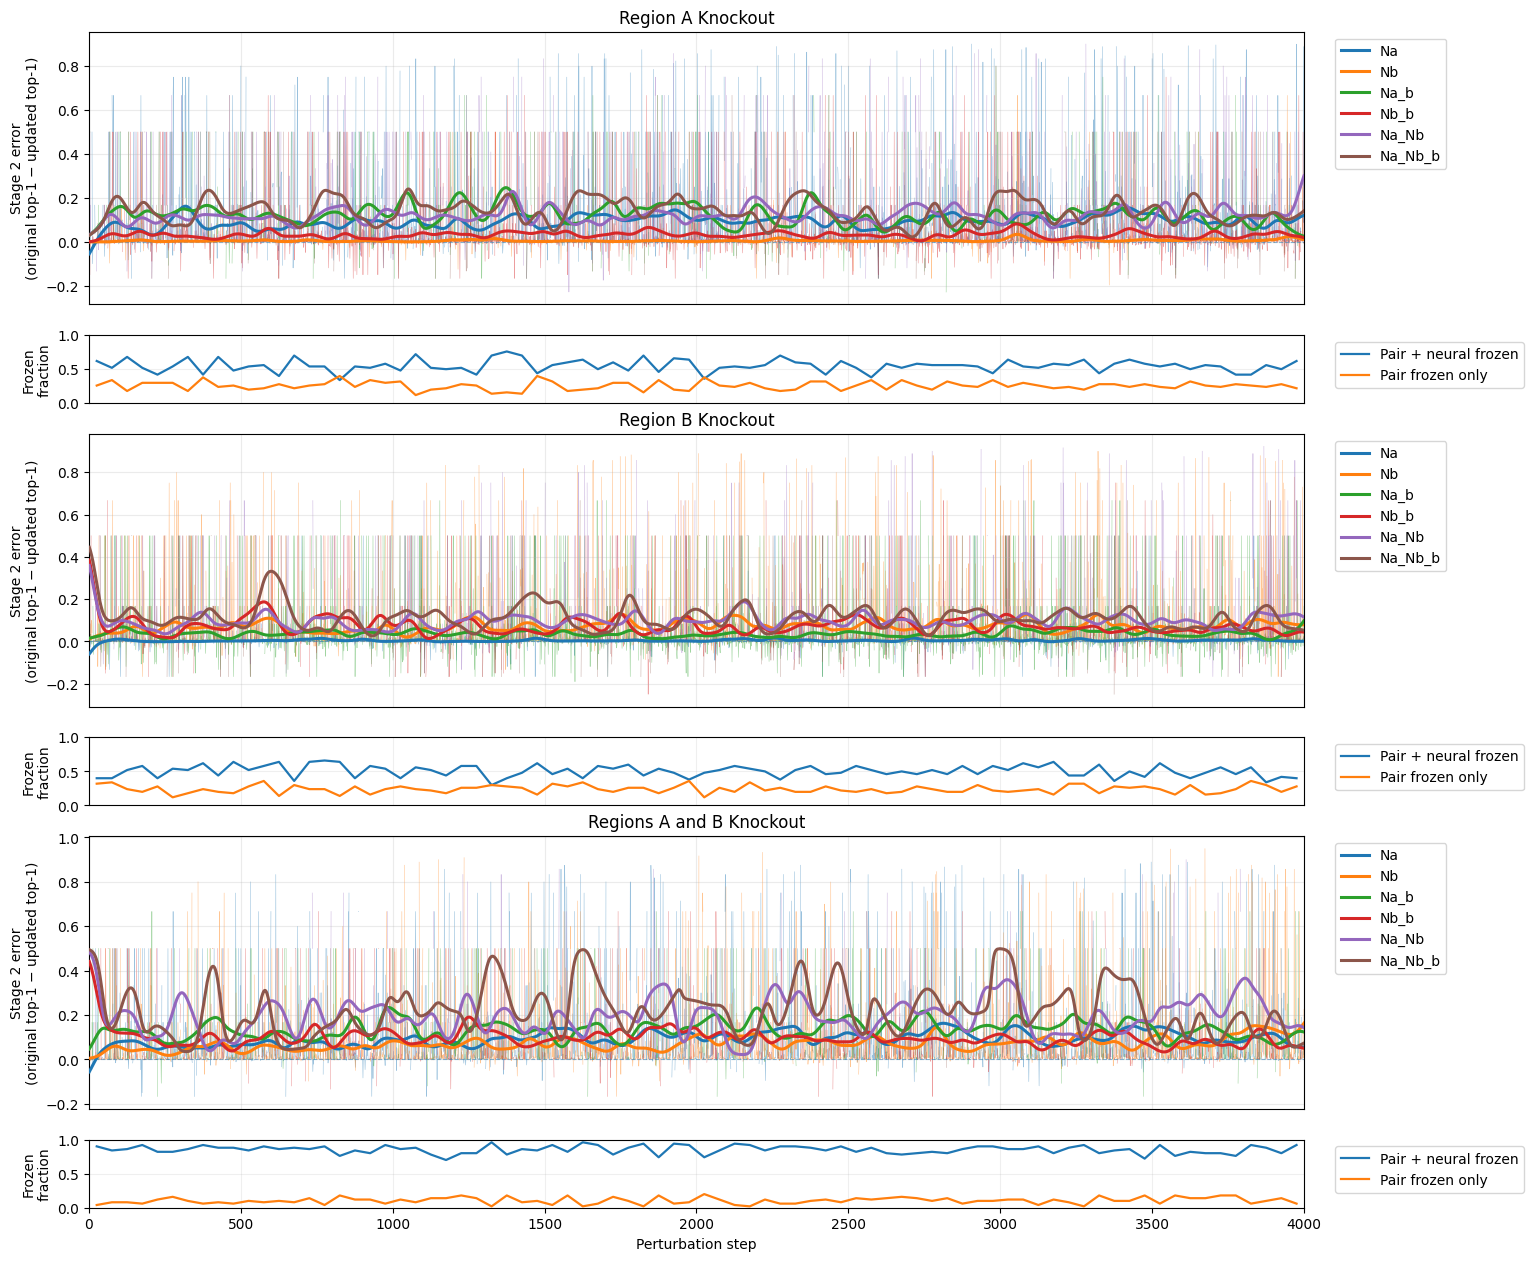

In [8]:
"""Stage 2 knockout perturbation plots for region A, B, and Both. The plots are smoothed via Gaussian smoothing with the raw error displayed faintly behind the 
smoothed plots. The frozen fraction graph below each plot displays the fraction of all steps that are either frozen in the pair transition dictionary only or
both the pair and neural transition dictionaries in a bin. A bin is defined as a 1 knockout perturbation in the sequence of 4000 per region (A, B, Both)."""
cma.plot_all_stage2_conditions(stage2_histories)

### Frozen States Summary

A neural state is considered frozen when it has no outgoing transitions in the original neural transition dictionary. It is a state that has never been seen before and causes the model to become stuck in a particular state. 

A pair state is considered frozen when the joint neural-behavioral state pair produced during perturbation trials has no outgoing transitions in the original joint transition dictionary.

In [9]:
for region in ("a", "b", "both"):
    history = stage2_histories[region]
    total = len(history)

    both_frozen = sum(row.get("both_frozen", False) for row in history)
    pair_only = sum(row.get("pair_only_frozen", False) for row in history)
    neural_only = sum(row.get("neural_only_frozen", False) for row in history)

    print(f"\nRegion: {region}")
    print(f"Pair + neural frozen: \n{both_frozen}/{total}\n{both_frozen / total:.1%})")
    print(f"Pair frozen only: \n{pair_only}/{total}\n{pair_only / total:.1%})")
    print(f"Neural frozen only: \n{neural_only}/{total} \n{neural_only / total:.1%})")


Region: a
Pair + neural frozen: 
2202/4000
55.0%)
Pair frozen only: 
1029/4000
25.7%)
Neural frozen only: 
0/4000 
0.0%)

Region: b
Pair + neural frozen: 
2022/4000
50.5%)
Pair frozen only: 
963/4000
24.1%)
Neural frozen only: 
0/4000 
0.0%)

Region: both
Pair + neural frozen: 
3411/4000
85.3%)
Pair frozen only: 
418/4000
10.4%)
Neural frozen only: 
0/4000 
0.0%)


## Behavioral State Analysis

Compare the behavioral-state distribution of the original model with the behavioral states visited during each perturbation condition.

The three perturbation conditions are analyzed separately because their perturbed trajectories can diverge even when they begin from the same initial conditions.

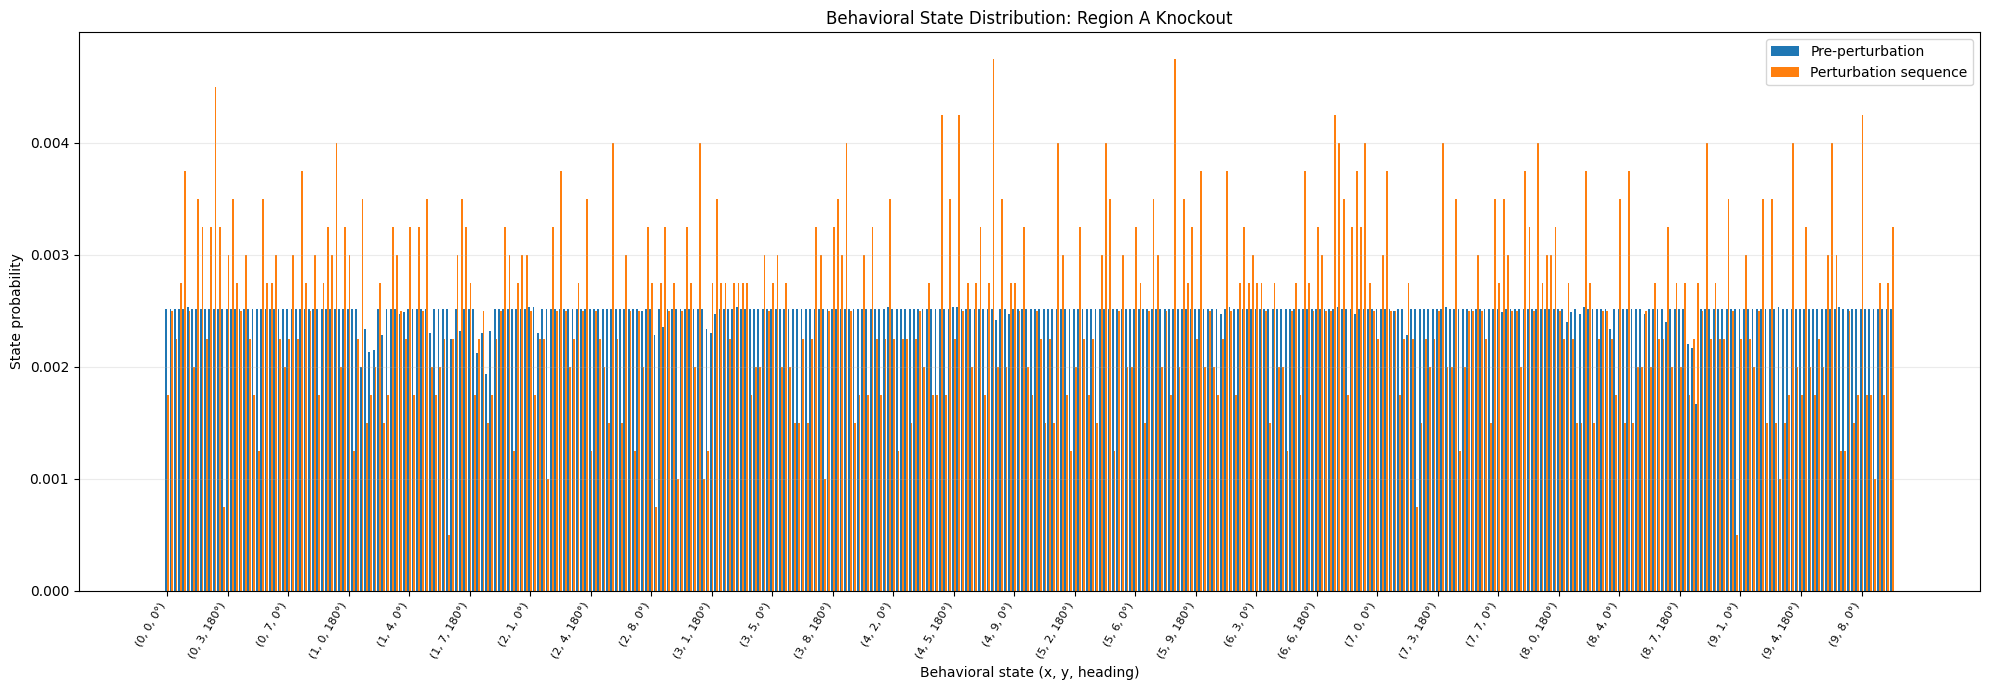

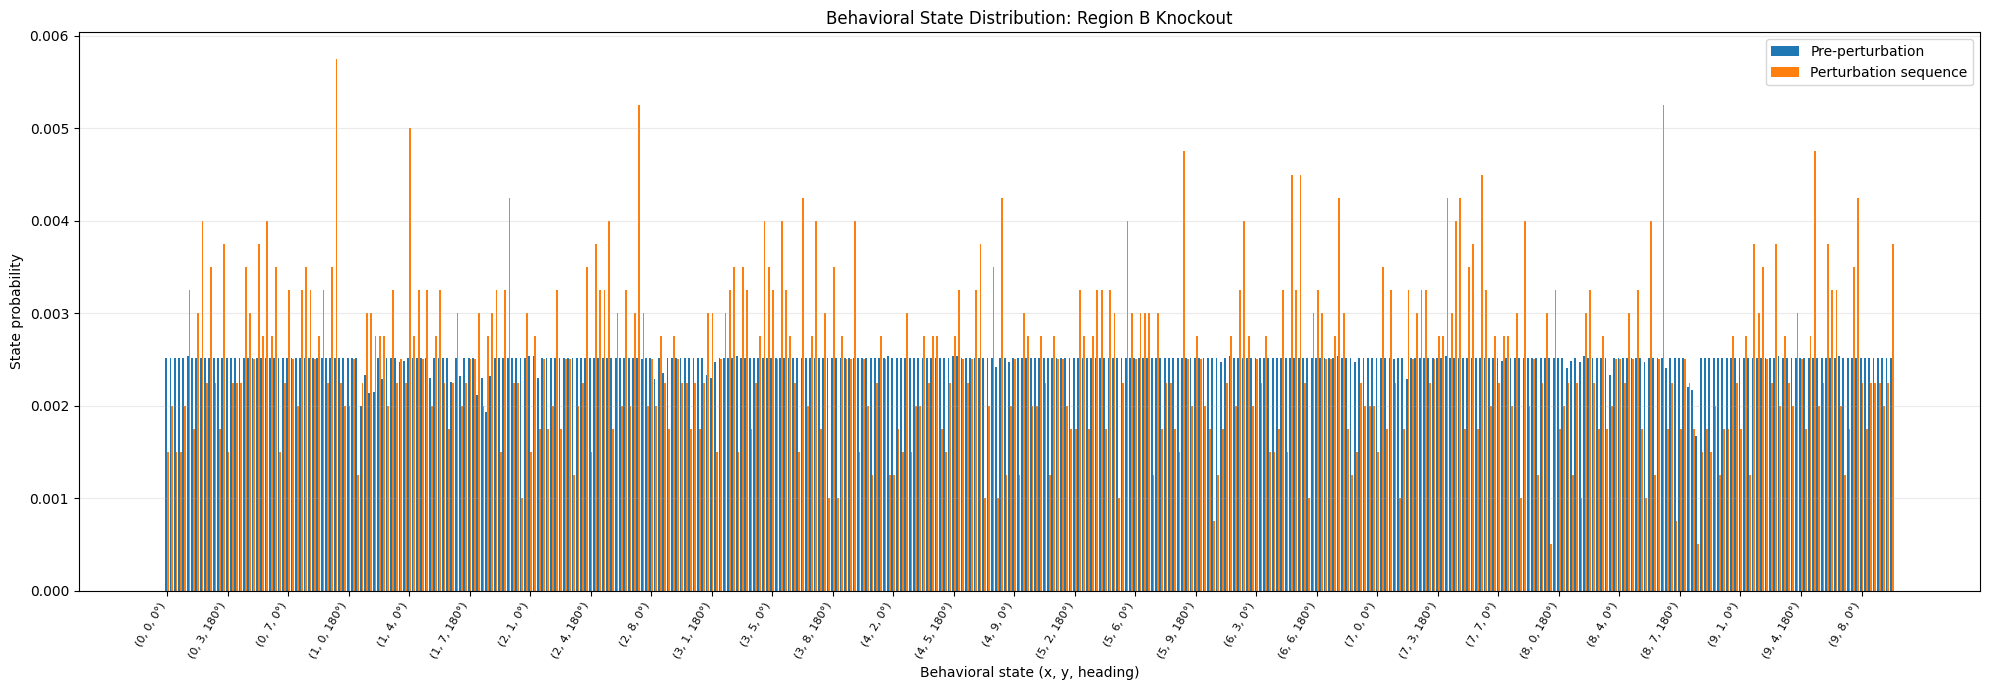

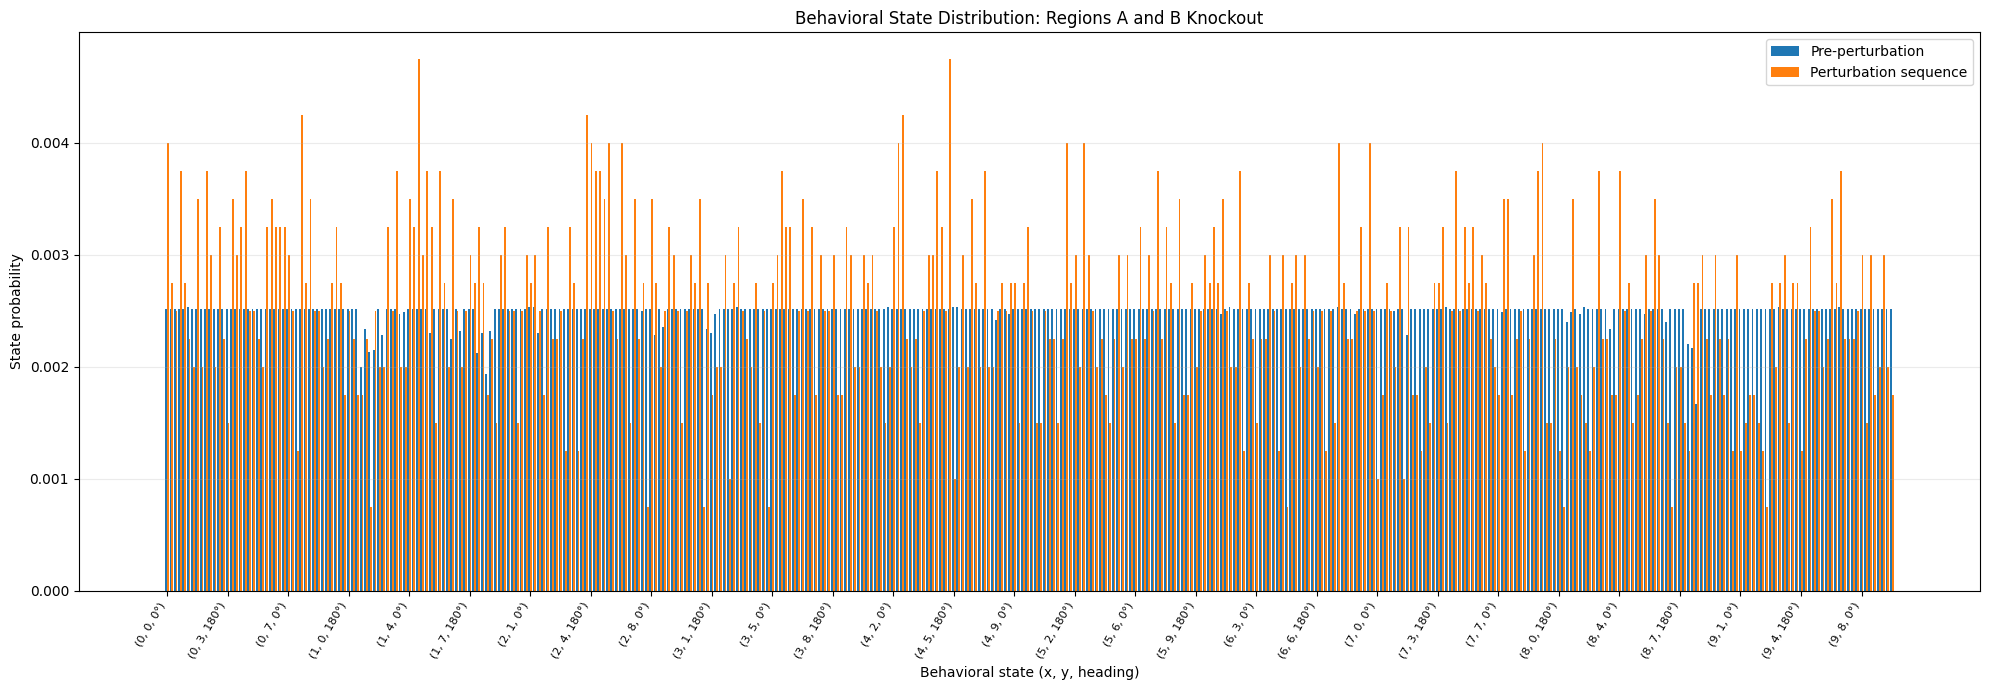

In [10]:
for region, title in [("a", "Region A Knockout"), ("b", "Region B Knockout"), ("both", "Regions A and B Knockout")]:
    cma.plot_b_distribution_pre_post(b_transition_dict, perturbation_results[region]["route"], title=f"Behavioral State Distribution: {title}")

### Behavioral State Similarity

Euclidean distance and Pearson Correlation is used to compare behavioral states from the original and perturbed transition dictionaries.

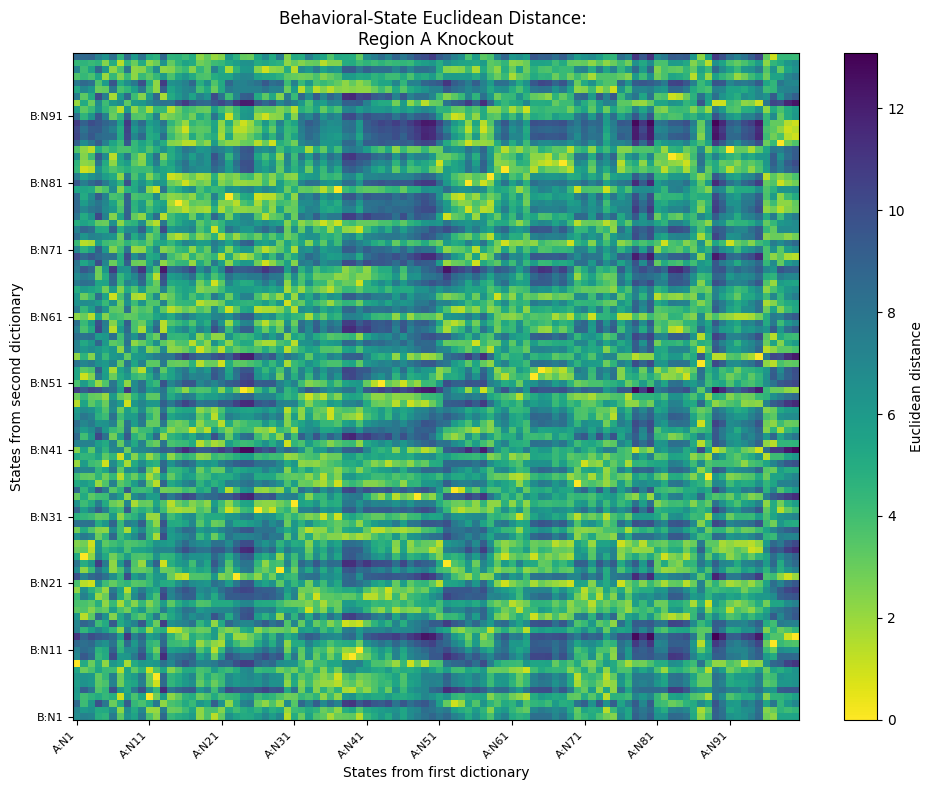

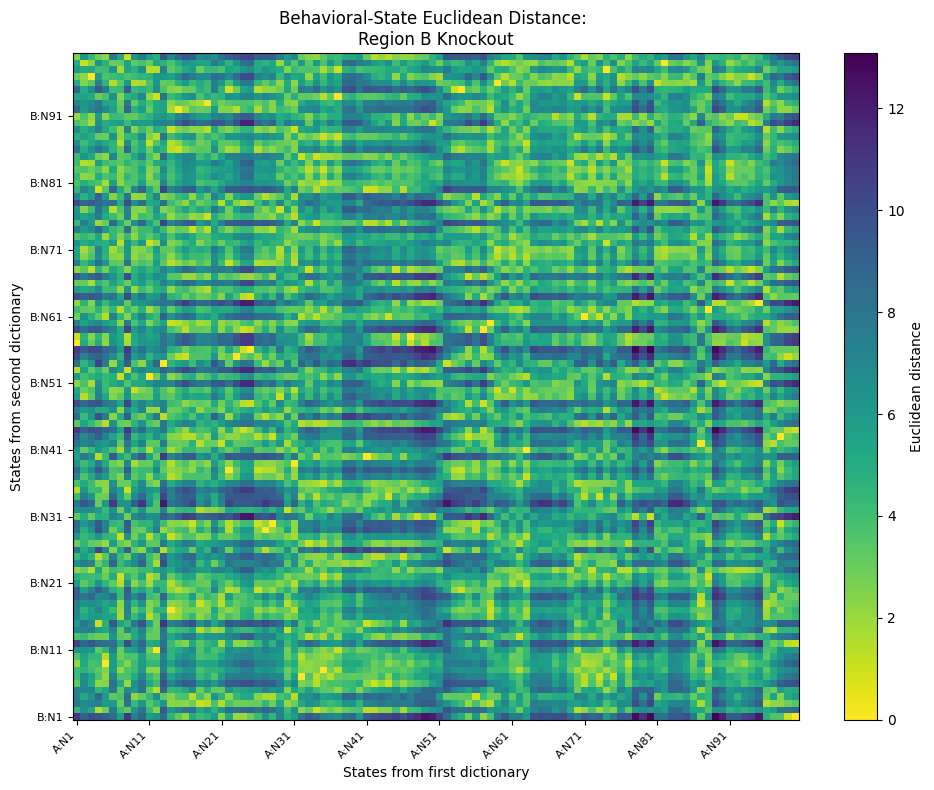

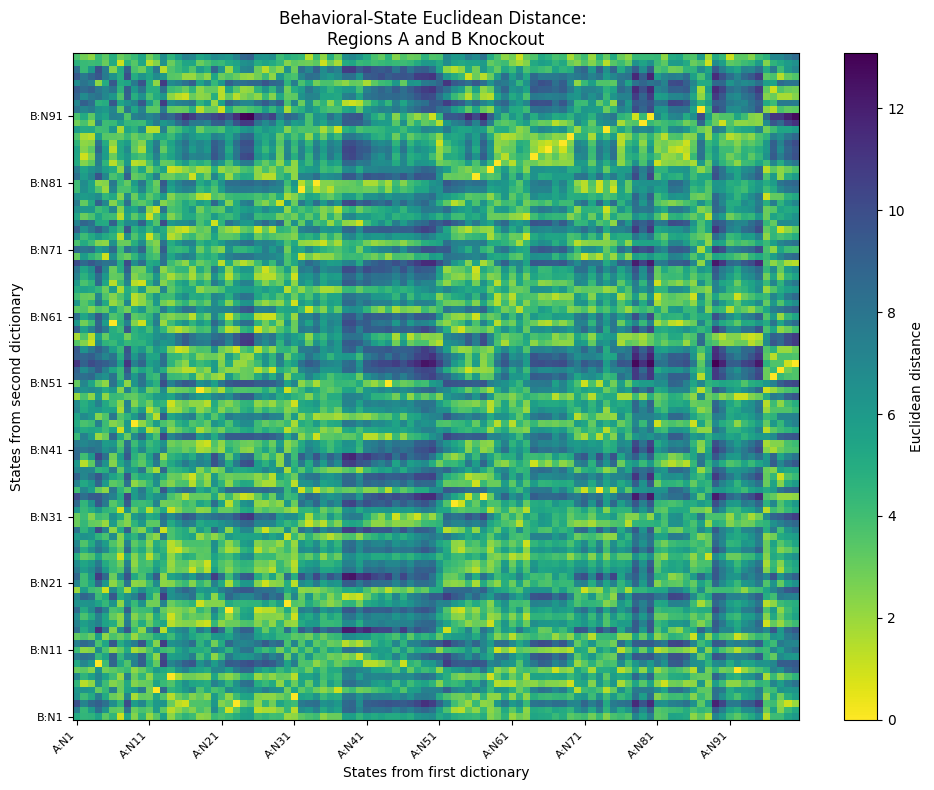

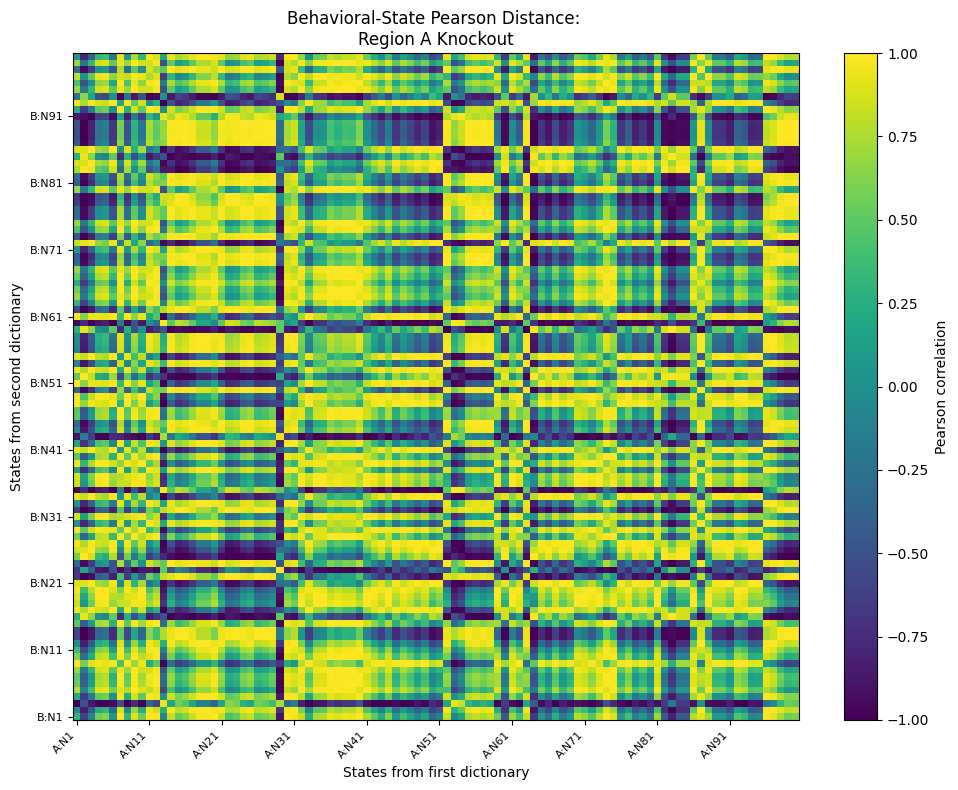

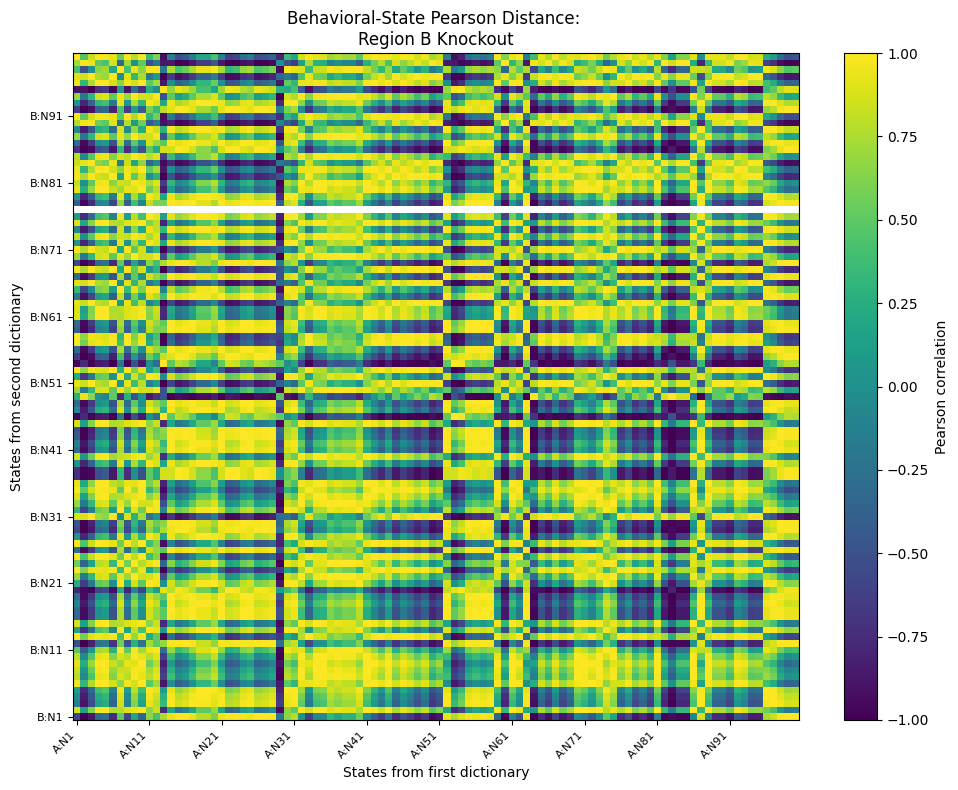

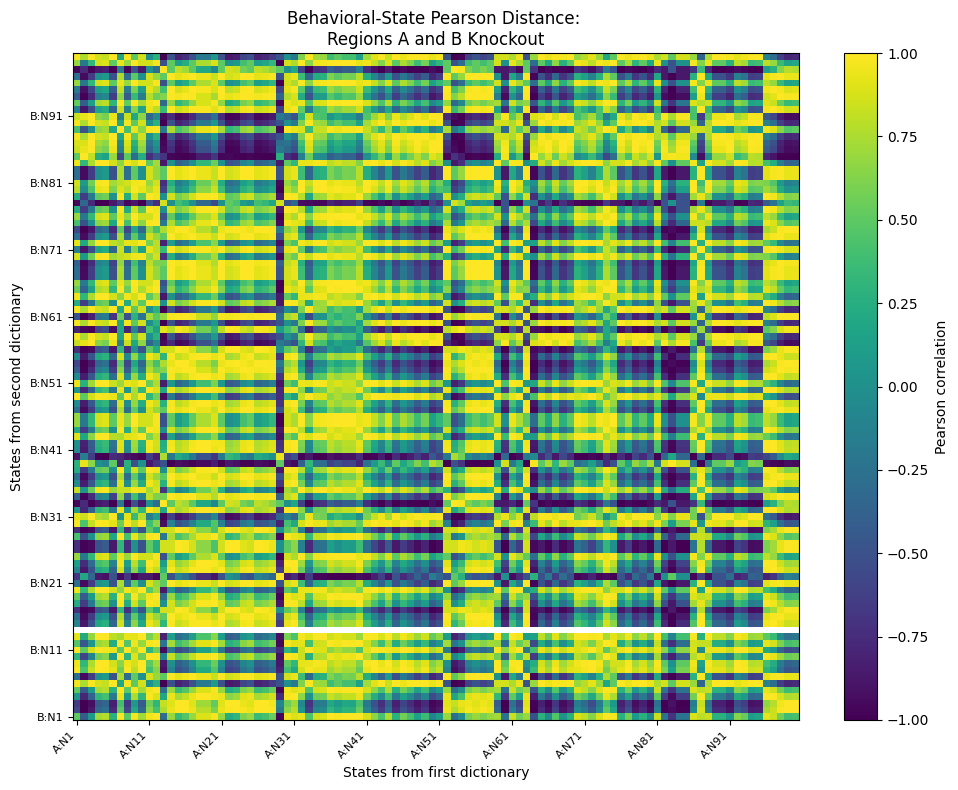

In [11]:
behavioral_matrices = {}

for region in ("a", "b", "both"):
    matrix, x_labels, y_labels, _, _ = cma.build_similarity_matrix(b_transition_dict, perturbation_results[region]["dicts"]["B"], metric="euclidean")
    behavioral_matrices[region] = ( matrix, x_labels, y_labels)

titles = {
    "a": "Region A Knockout",
    "b": "Region B Knockout",
    "both": "Regions A and B Knockout"
}

for region in ("a", "b", "both"):
    matrix, x_labels, y_labels = behavioral_matrices[region]

    cma.plot_euclidean_matrix(matrix, x_labels, y_labels, title=(f"Behavioral-State Euclidean Distance: \n{titles[region]}"))

for region in ("a", "b", "both"):
    matrix, x_labels, y_labels, _, _ = cma.build_similarity_matrix(b_transition_dict, perturbation_results[region]["dicts"]["B"], metric="pearson")
    behavioral_matrices[region] = ( matrix, x_labels, y_labels)

titles = {
    "a": "Region A Knockout",
    "b": "Region B Knockout",
    "both": "Regions A and B Knockout"
}

for region in ("a", "b", "both"):
    matrix, x_labels, y_labels = behavioral_matrices[region]

    cma.plot_pearson_matrix(matrix, x_labels, y_labels, title=(f"Behavioral-State Pearson Distance: \n{titles[region]}"))

## Stage 3: Fixed-Route Transition Error

Stage 3 evaluates predicted transition accuracy along a fixed route generated from the original connected-RNN transition dictionary.

Unlike Stage 2, the trajectory itself does not change after perturbation. The same original route is evaluated using the transition probabilities contained in each post-perturbation dictionary.

In [12]:
original_connected_dicts = {
    "B": b_transition_dict,
    "Na": Na_transition_dict,
    "Nb": Nb_transition_dict,
    "Na_b": Na_b_transition_dict,
    "Nb_b": Nb_b_transition_dict,
    "Na_Nb": Na_Nb_transition_dict,
    "Na_Nb_b": Na_Nb_b_transition_dict
}

print("Original connected transition dictionaries ready.")

Original connected transition dictionaries ready.


In [13]:
stage3_route = cma.generate_connected_route(Na_Nb_b_transition_dict, route_length=50, seed=SEED)

print("Stage 3 route length:", len(stage3_route))
print("First route state:", stage3_route[0])

Stage 3 route length: 50
First route state: ((0, 0, 3), (0.0, 0.0, 0.3, 0.0, 0.0, 0.0, -0.3, 0.0, 0.6, -0.3), (0.0, 0.3, -0.3, 0.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0), (0, 4, 2), (0.0, 0.0, 0.3, -0.6, -0.3, 0.0, 0.0, 0.3, 0.6, -0.6), (0.3, 0.3, -0.3, 0.0, 0.3, 0.0, -0.3, 0.0, 0.0, 0.0), 1)


### Pre- and Post-Perturbation Stage 3 Error

For every state on the fixed route, Stage 3 error compares the highest-probability outgoing transition with the transition actually specified by the route.

The original and perturbed transition dictionaries are evaluated at the same route sequence.

In [14]:
original_stage3_history = cma.calc_connected_stage3_error_history(stage3_route, original_connected_dicts)

print("Original Stage 3 transitions:", len(original_stage3_history))

Original Stage 3 transitions: 50


In [15]:
stage3_histories = {}

for region in ("a", "b", "both"):
    stage3_histories[region] = cma.calc_connected_stage3_error_history(stage3_route, perturbation_results[region]["dicts"])
    print(f"{region}: \n{len(stage3_histories[region])} Stage 3 transitions")

a: 
50 Stage 3 transitions
b: 
50 Stage 3 transitions
both: 
50 Stage 3 transitions


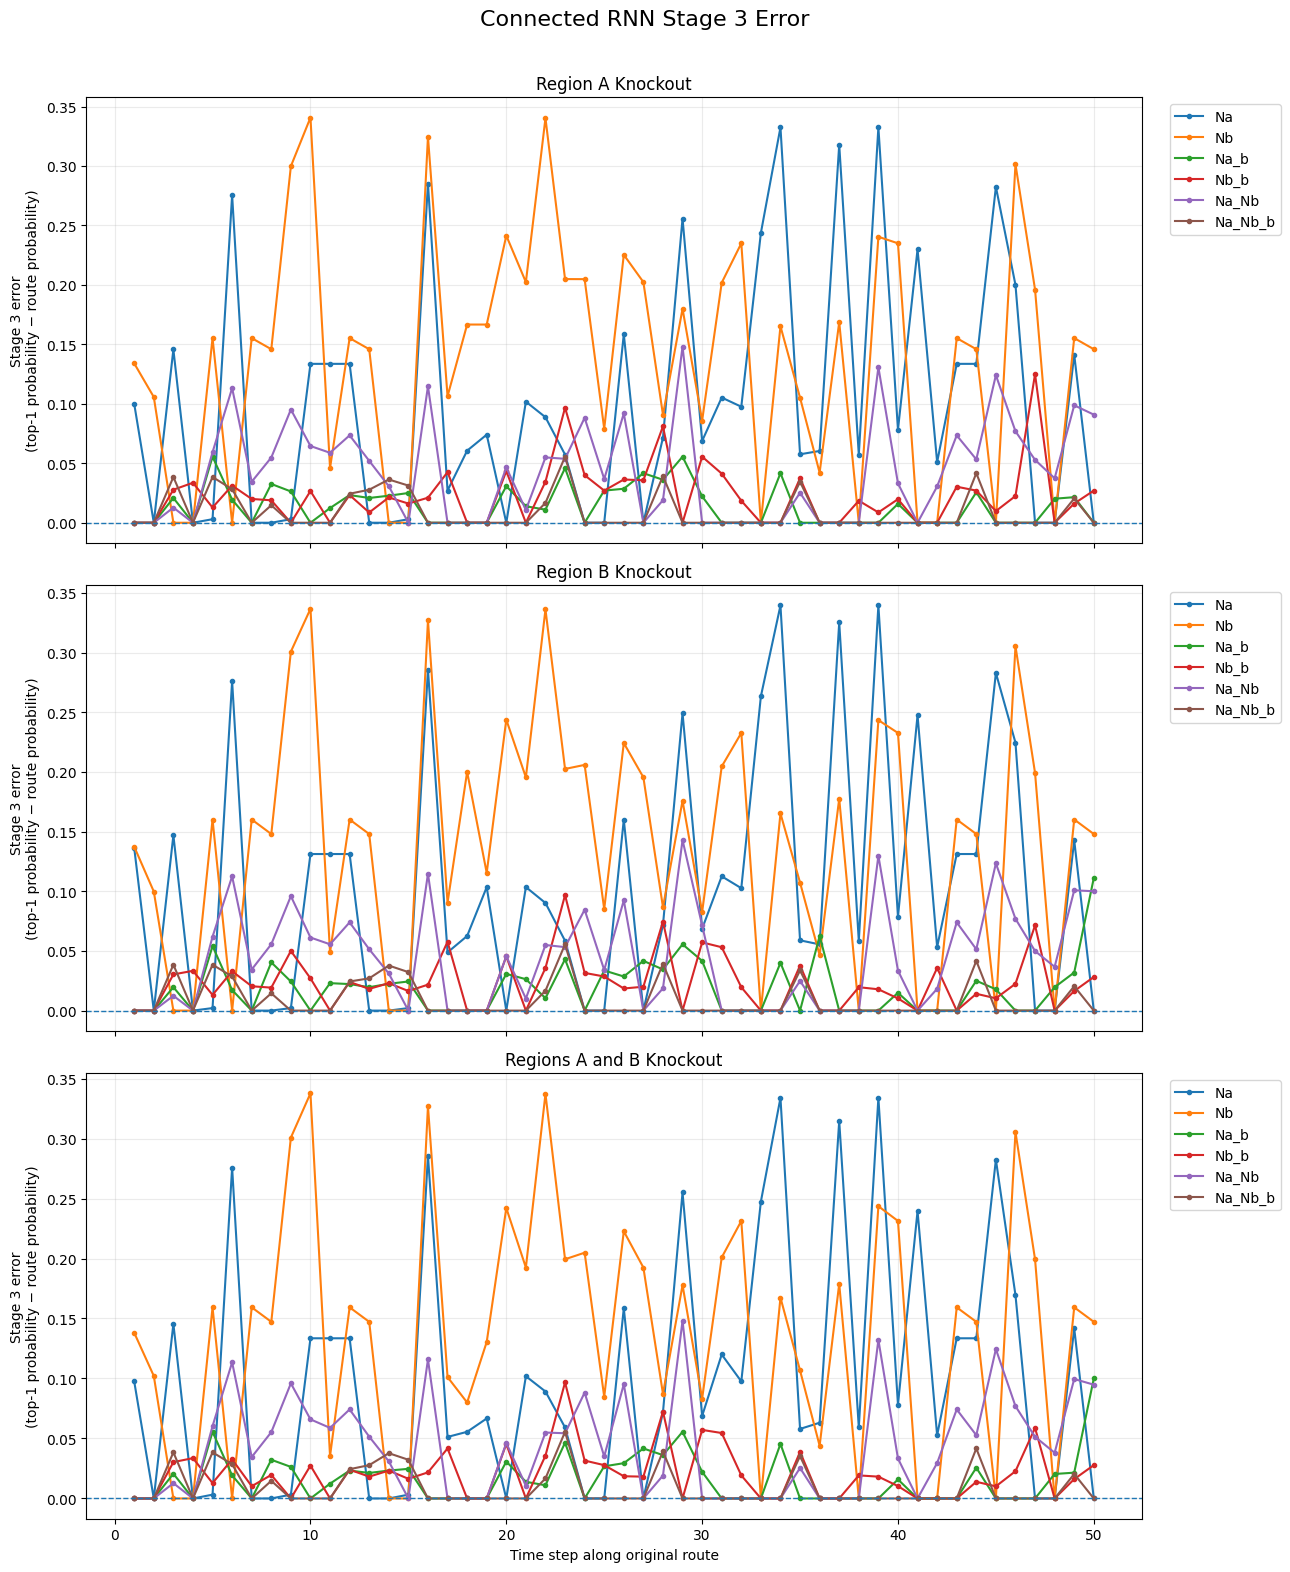

In [16]:
cma.plot_all_stage3_conditions(stage3_histories)

## Stage 2 +/- Error

Stage 2 errors are grouped into bins of step size 200 to show how frequently the perturbation increases or decreases the top-transition probability relative to the original transition dictionary.

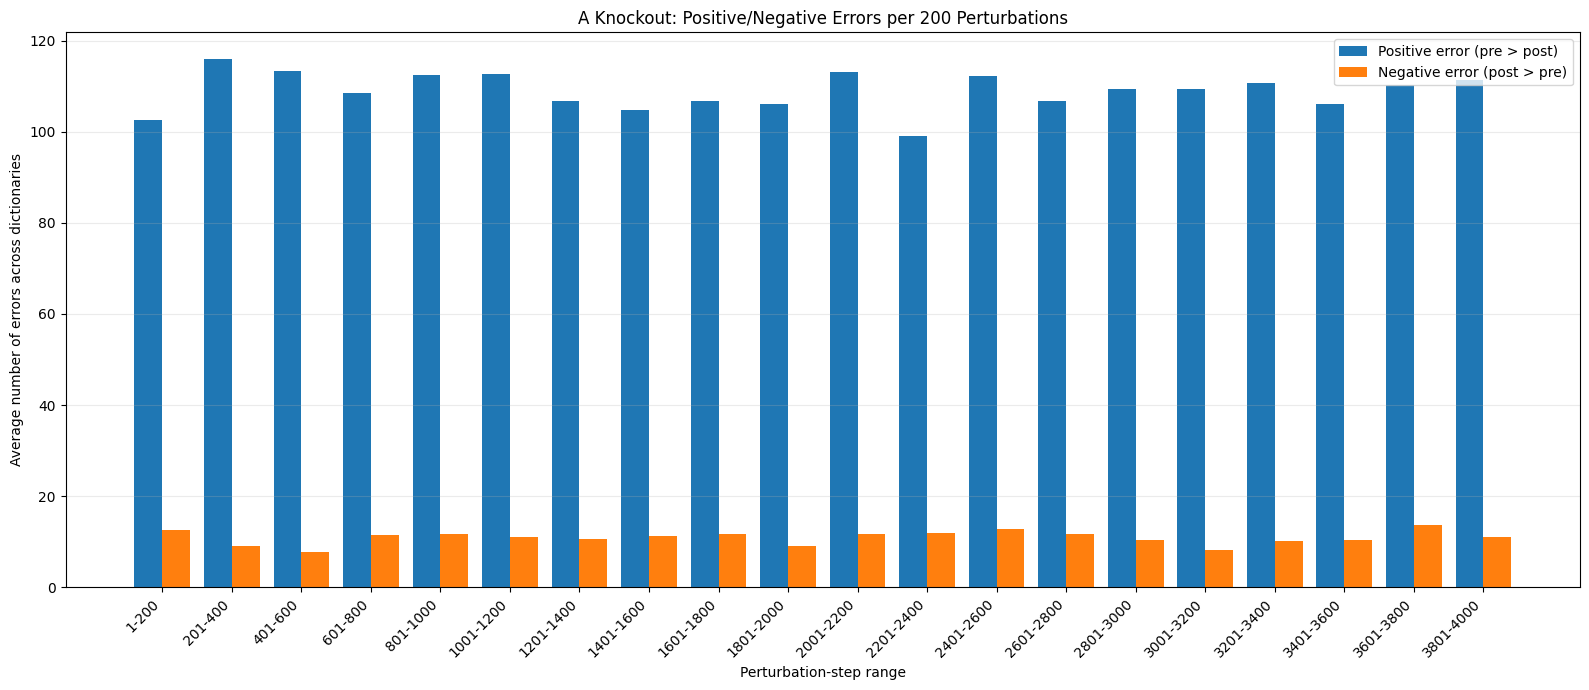

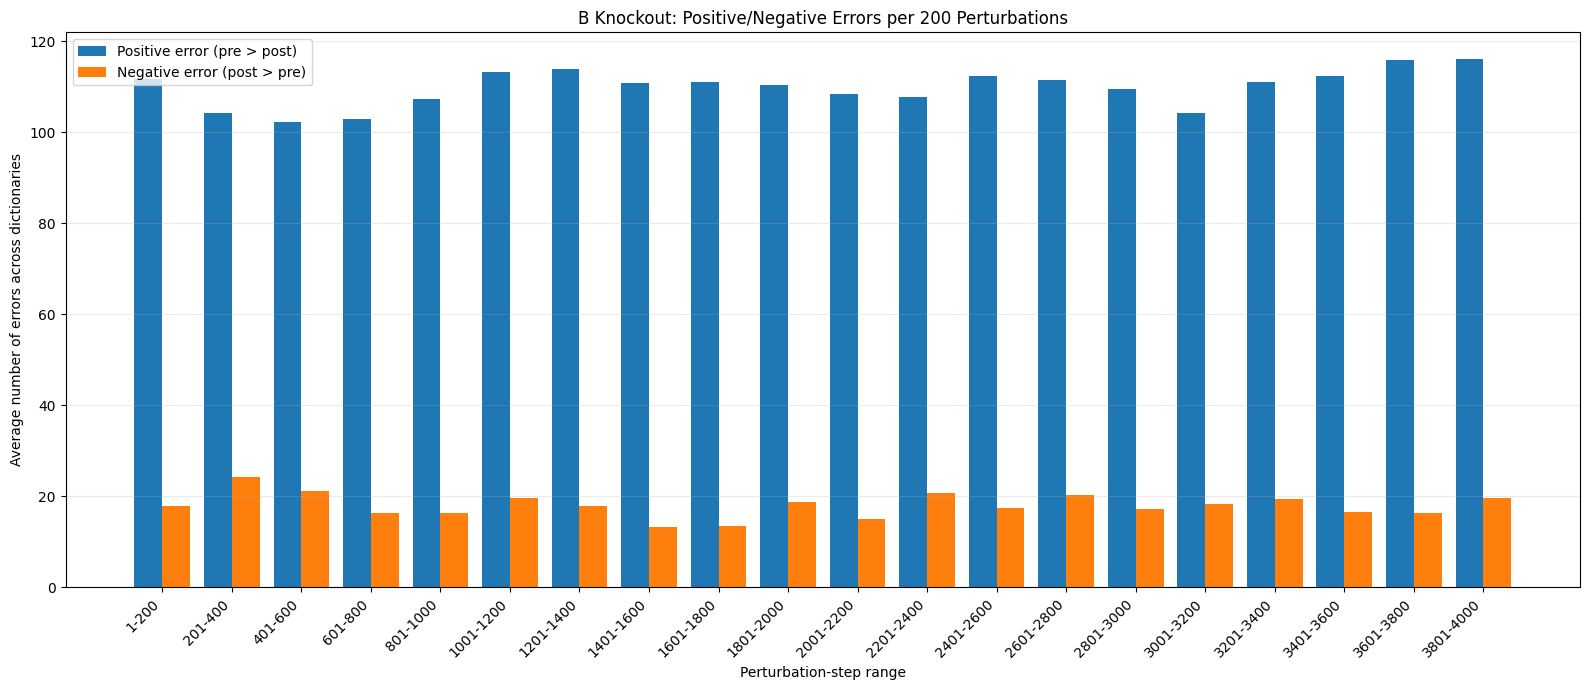

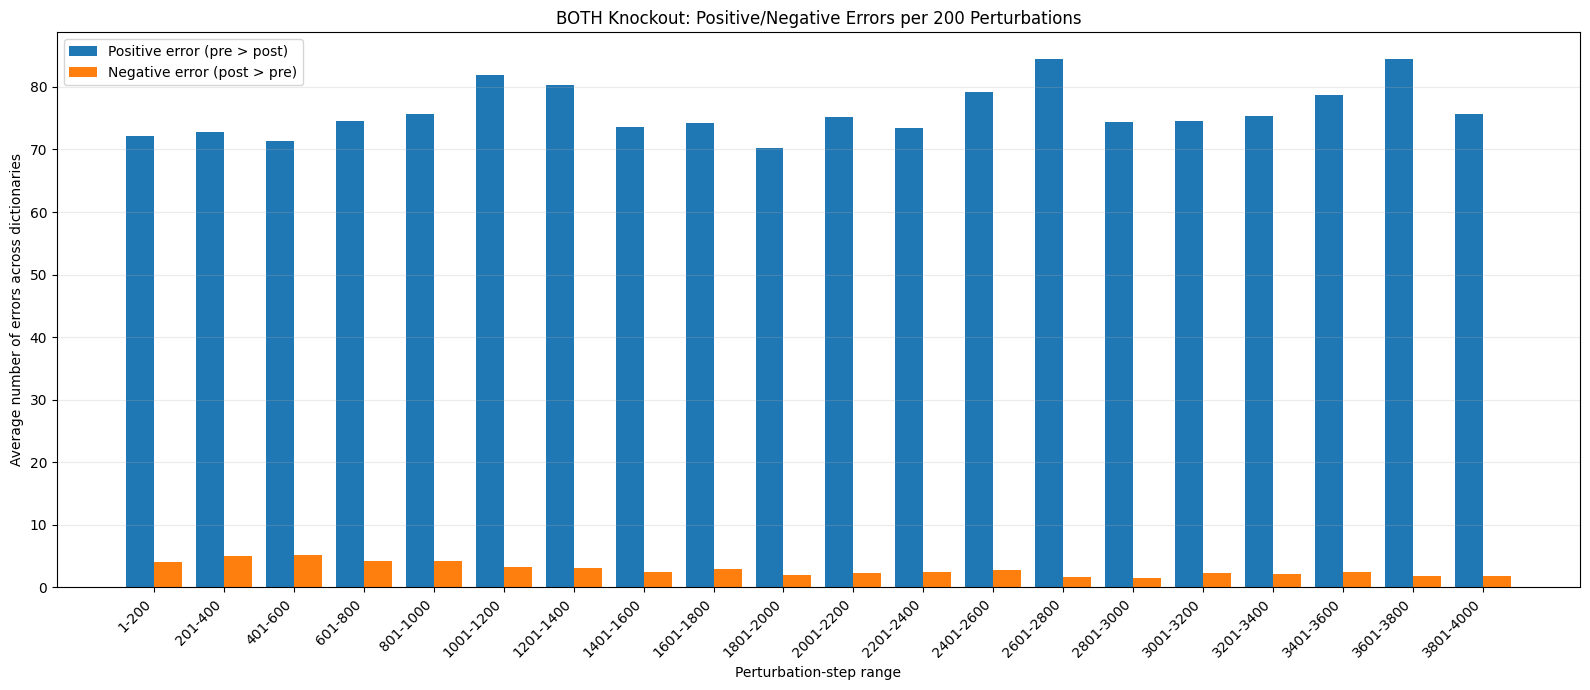

In [17]:
for region in ("a", "b", "both"):
    cma.plot_signed_errors_histogram(stage2_histories[region], bin_size=200, title=f"{region.upper()} Knockout: Positive/Negative Errors per 200 Perturbations")
    

## Fixed-Route Pre/Post Perturbation Error

A fixed 50-step route generated from the original connected-RNN transition dictionary is evaluated before and after each perturbation condition.

In [18]:
route = cma.generate_connected_route(Na_Nb_b_transition_dict, route_length=50, seed=SEED)

original_dicts = {
    "Na": Na_transition_dict,
    "Nb": Nb_transition_dict,
    "Na_b": Na_b_transition_dict,
    "Nb_b": Nb_b_transition_dict,
    "Na_Nb": Na_Nb_transition_dict,
    "Na_Nb_b": Na_Nb_b_transition_dict,
    "B": b_transition_dict
}

pre_error_history = cma.calc_connected_stage3_error_history(route, original_dicts)

print("Fixed route length:", len(route))
print("Pre-perturbation error history:", len(pre_error_history))

Fixed route length: 50
Pre-perturbation error history: 50


In [19]:
post_error_histories = {}
error_change_histories = {}

for region in ("a", "b", "both"):
    updated_dicts = perturbation_results[region]["dicts"]

    post_error_histories[region] = cma.calc_connected_stage3_error_history(route, updated_dicts)
    error_change_histories[region] = cma.calc_connected_error_change(pre_error_history, post_error_histories[region])

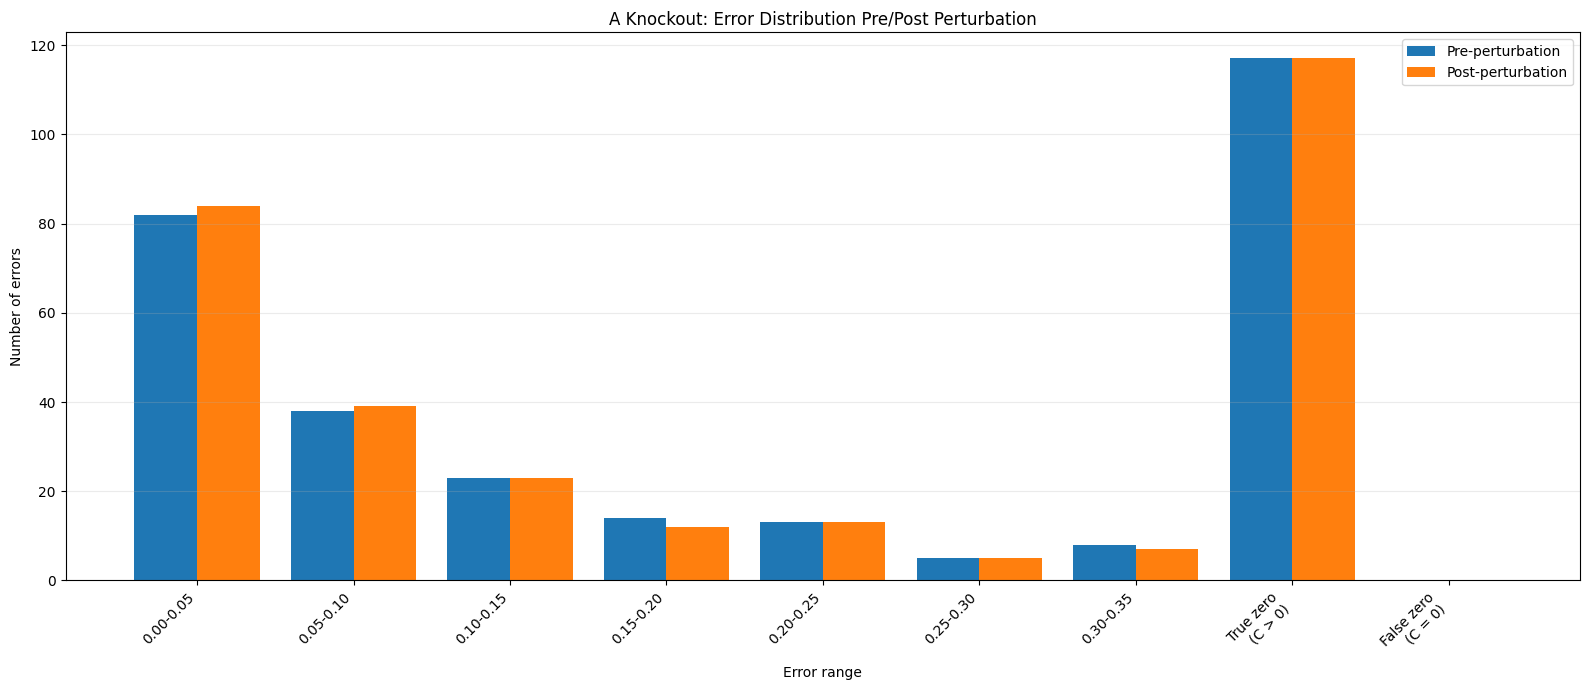

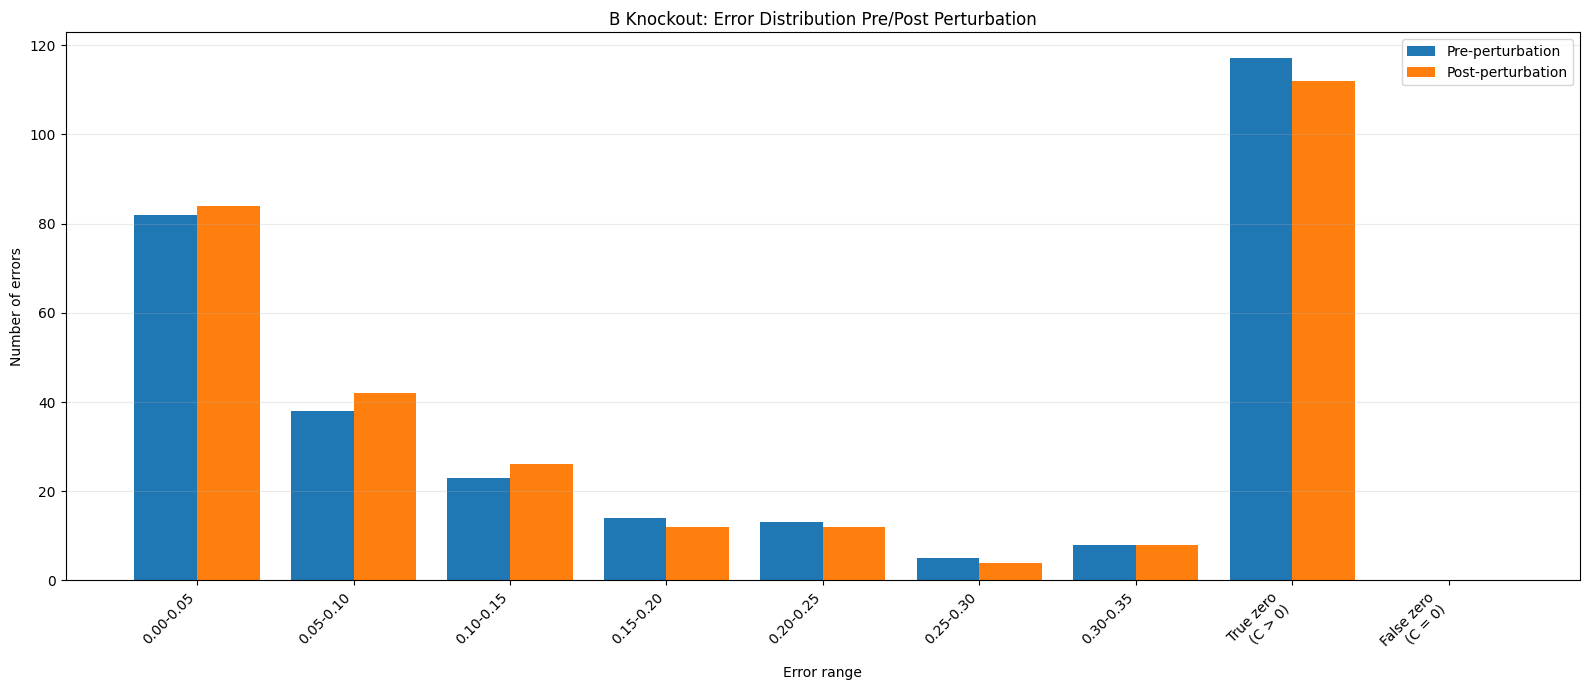

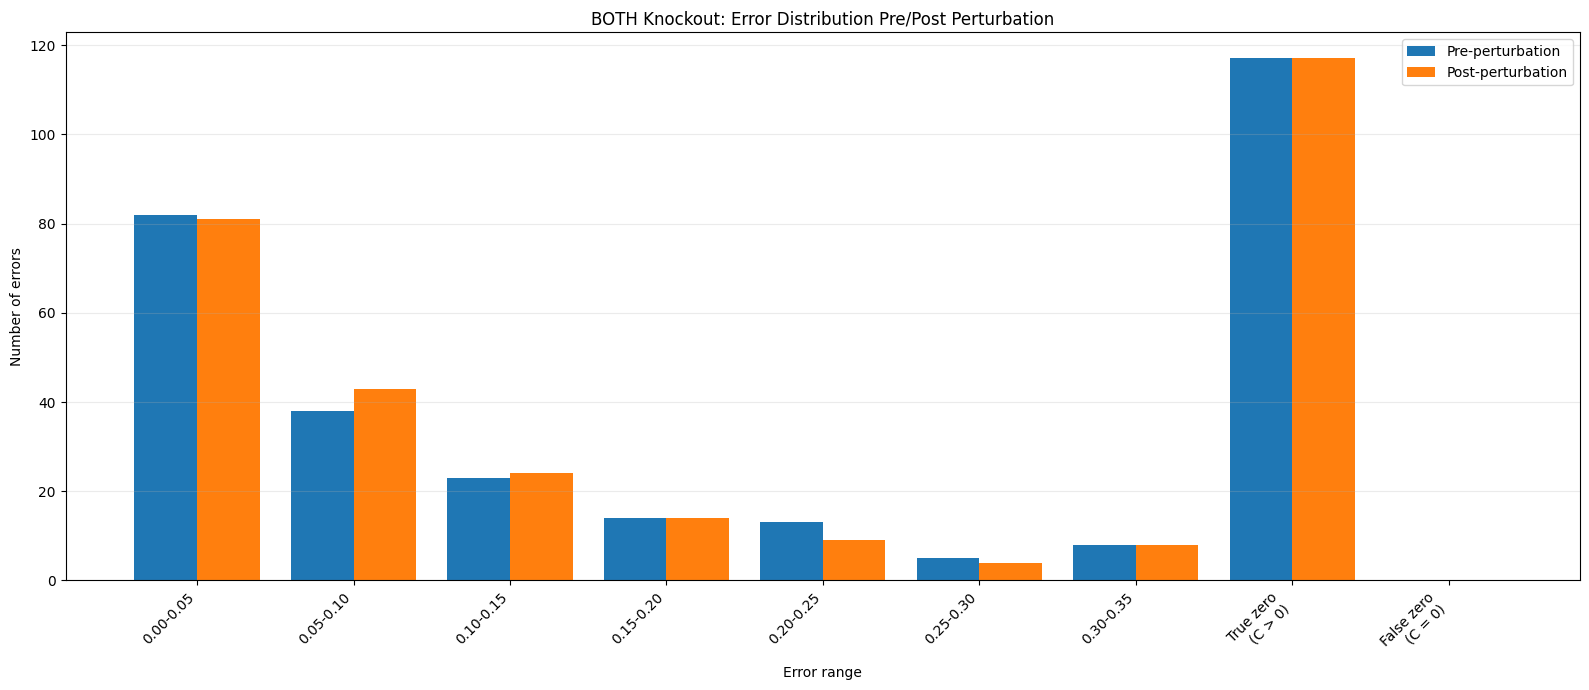

In [20]:
for region in ("a", "b", "both"):
    cma.plot_pre_post_error_distribution(pre_error_history, post_error_histories[region], error_bin_width=0.05, title=f"{region.upper()} Knockout: Error Distribution Pre/Post Perturbation")

## Change in Fixed-Route Error After Knockout

This analysis shows the change in Stage 3 error at each step of the fixed original route after perturbation.

Positive values indicate that error increased after perturbation, while negative values indicate that error decreased after perturbation.

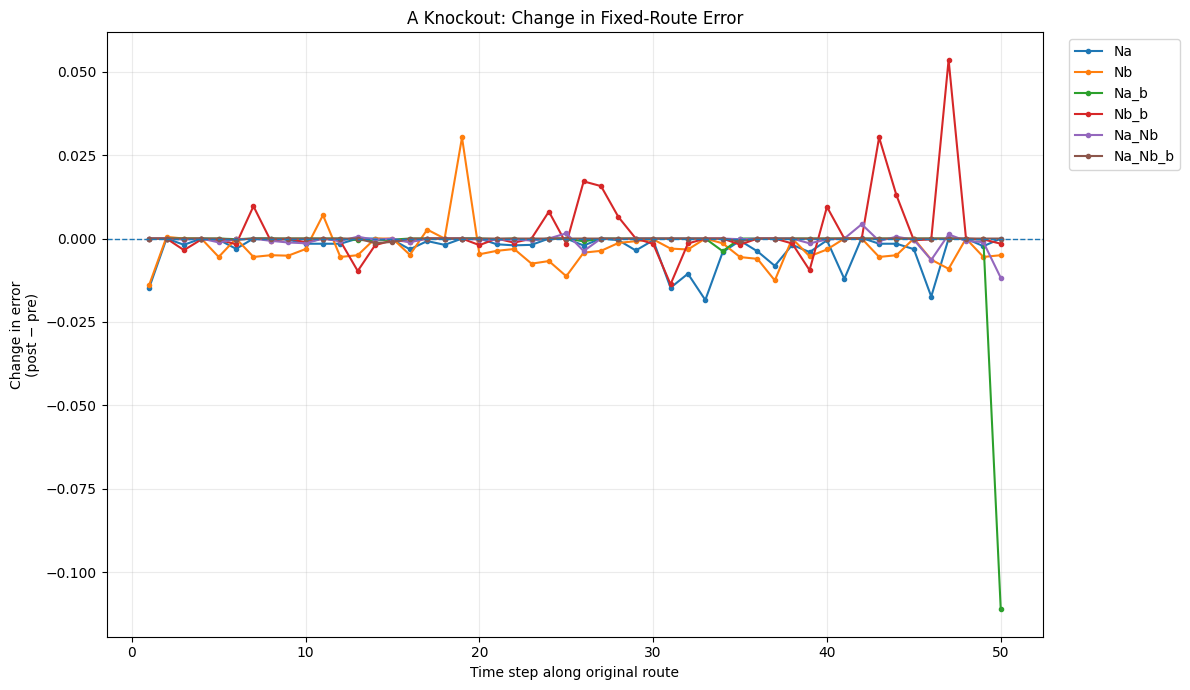

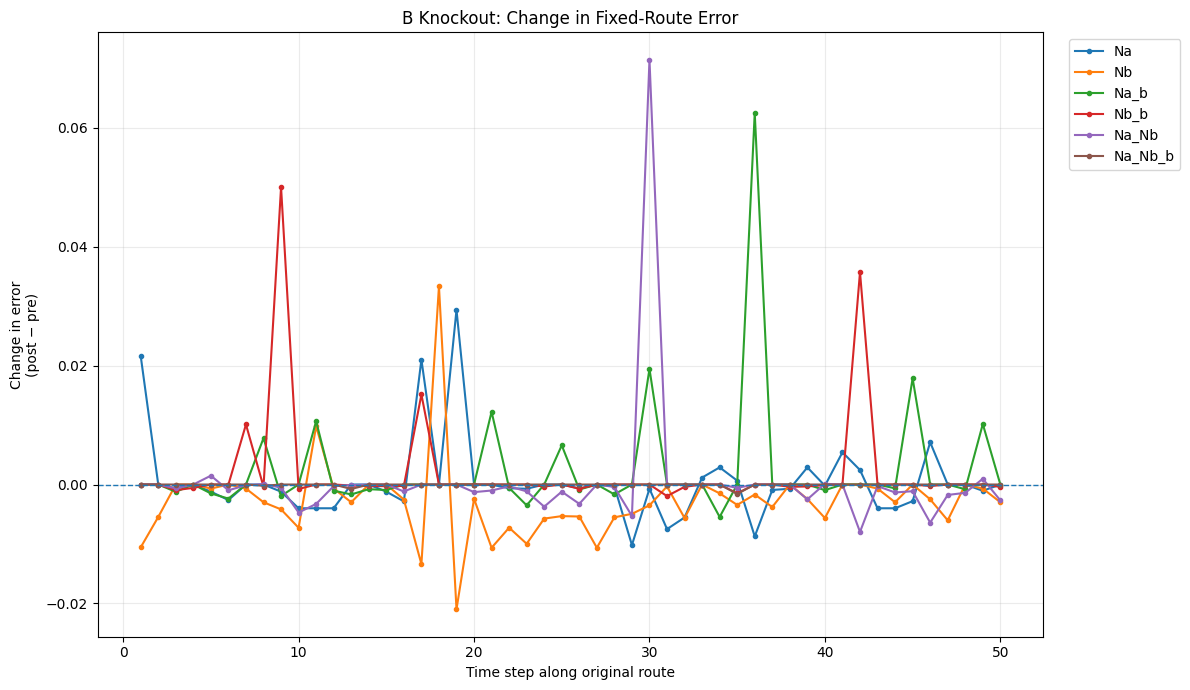

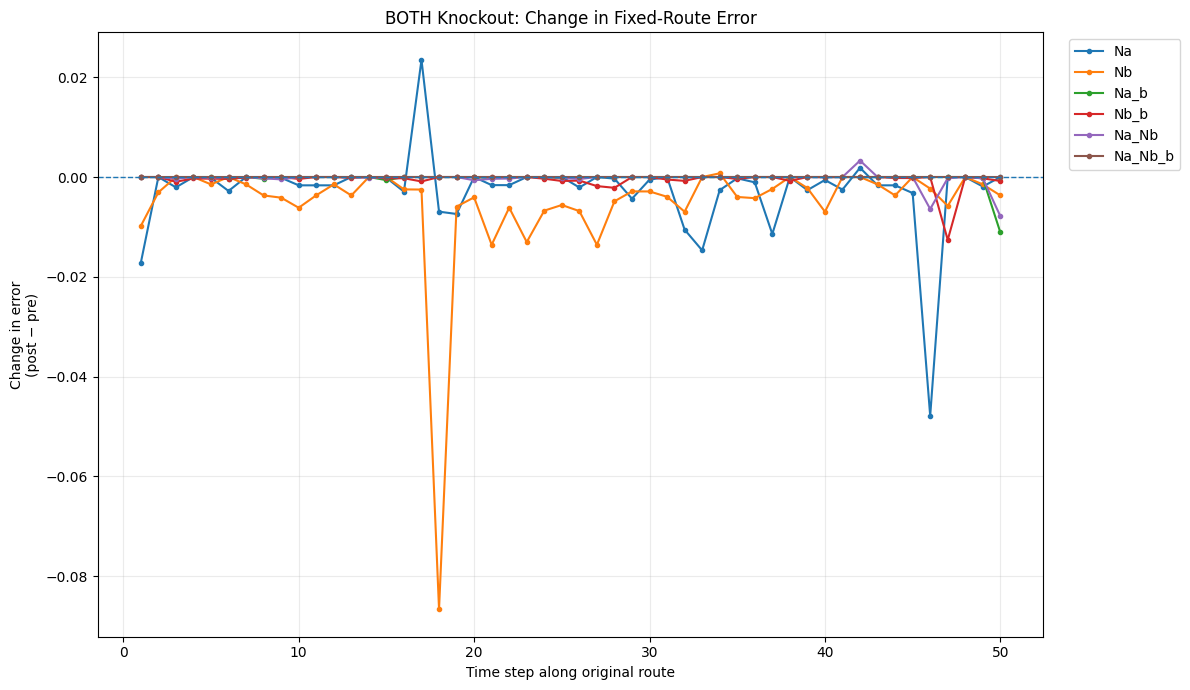

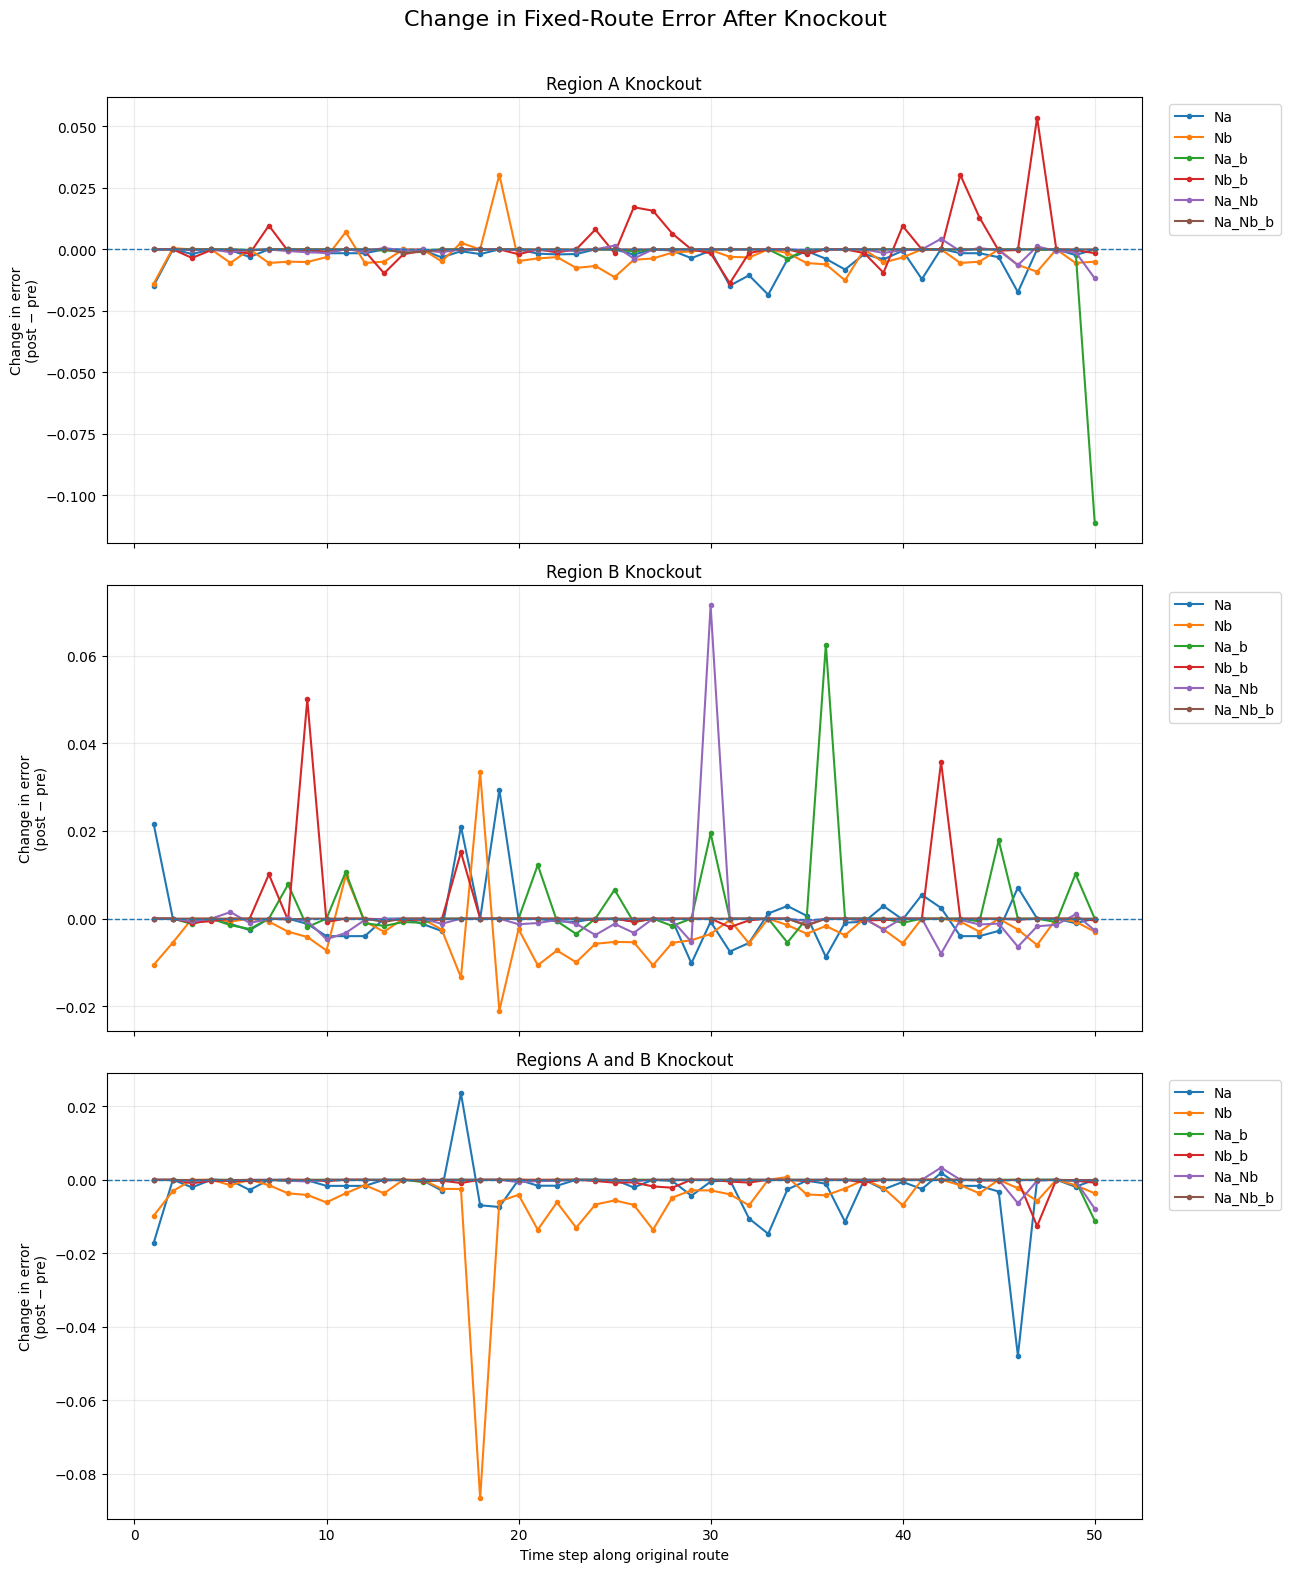

In [21]:
for region in ("a", "b", "both"):
    cma.plot_connected_error_change(error_change_histories[region], title=f"{region.upper()} Knockout: Change in Fixed-Route Error")

cma.plot_all_error_change_conditions(error_change_histories)